In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving drug.csv to drug.csv
Saving iris (1).csv to iris (1).csv
Saving petrol_consumption.csv to petrol_consumption.csv
User uploaded file "drug.csv" with length 6029 bytes
User uploaded file "iris (1).csv" with length 4617 bytes
User uploaded file "petrol_consumption.csv" with length 1211 bytes


Dataset:
     Age Sex      BP Cholesterol  Na_to_K   Drug
0     23   F    HIGH        HIGH   25.355  drugY
1     47   M     LOW        HIGH   13.093  drugC
2     47   M     LOW        HIGH   10.114  drugC
3     28   F  NORMAL        HIGH    7.798  drugX
4     61   F     LOW        HIGH   18.043  drugY
..   ...  ..     ...         ...      ...    ...
195   56   F     LOW        HIGH   11.567  drugC
196   16   M     LOW        HIGH   12.006  drugC
197   52   M  NORMAL        HIGH    9.894  drugX
198   23   M  NORMAL      NORMAL   14.020  drugX
199   40   F     LOW      NORMAL   11.349  drugX

[200 rows x 6 columns]

Encoded Dataset:
     Age  Sex  BP  Cholesterol  Na_to_K  Drug
0      8    0   0            0      167     4
1     30    1   1            0       89     2
2     30    1   1            0       43     2
3     12    0   2            0       10     3
4     44    0   1            0      133     4
..   ...  ...  ..          ...      ...   ...
195   39    0   1            0       69

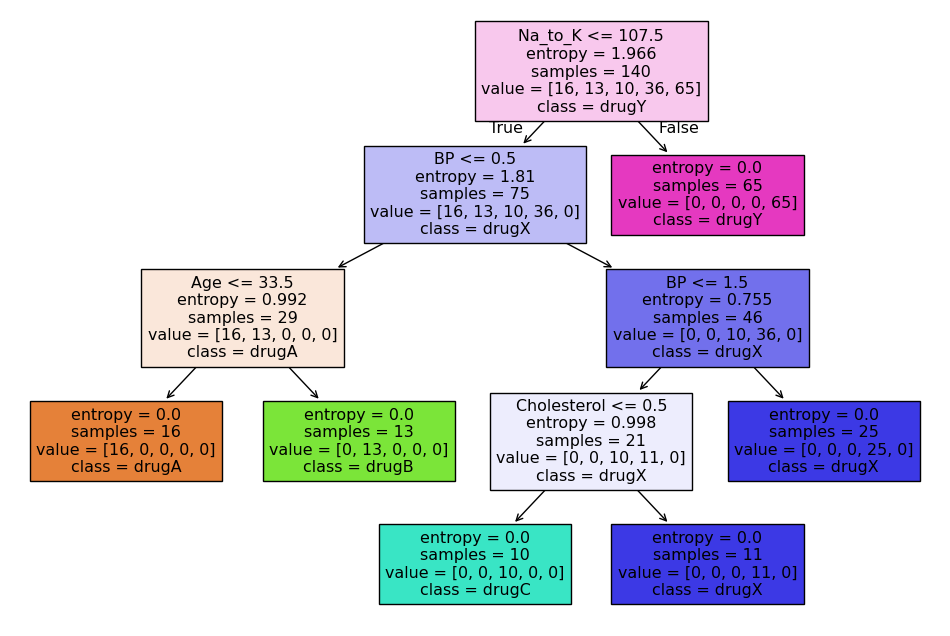

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Load CSV file
df = pd.read_csv("drug.csv")

print("Dataset:")
print(df)

# Step 2: Encode categorical values
label_encoders = {}

for column in df.columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

print("\nEncoded Dataset:")
print(df)

# Step 3: Split features and target
X = df.drop("Drug", axis=1)  # Changed 'Classification' to 'Drug'
y = df["Drug"]  # Changed 'Classification' to 'Drug'

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 5: Train decision tree
clf = DecisionTreeClassifier(criterion="entropy")
clf.fit(X_train, y_train)

# Step 6: Predictions
y_pred = clf.predict(X_test)

print("\nPredictions:", y_pred)
print("Actual:", y_test.values)

# Step 7: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Step 8: Visualize decision tree
plt.figure(figsize=(12,8))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=label_encoders['Drug'].classes_ # Dynamically set class names
)
plt.show()